In [23]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

%matplotlib inline

In [24]:
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, average_precision_score
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier

In [25]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"

sys.path.append(str(SRC_PATH))

In [26]:
from preprocessing import build_pipeline, clean_stroke_data
from metrics import evaluate_model, find_optimal_threshold, evaluate_model_v2

In [27]:
# set global seaborn style
sns.set_theme(
    context="notebook",
    style="ticks",
    palette="colorblind",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## Data Cleaning

In [28]:
df = pd.read_csv("../data/raw/stroke.csv")

In [29]:
df = clean_stroke_data(df)

In [30]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,male,67.0,0,1,1,private,urban,228.69,36.6,formerly_smoked,1
1,female,61.0,0,0,1,self-employed,rural,202.21,NaN,never_smoked,1
2,male,80.0,0,1,1,private,rural,105.92,32.5,never_smoked,1
3,female,49.0,0,0,1,private,urban,171.23,34.4,smokes,1
4,female,79.0,1,0,1,self-employed,rural,174.12,24.0,never_smoked,1


## Tuning

In [31]:
X = df.drop(columns=["stroke"])
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [32]:
print("Train Stroke Rate:", y_train.mean())
print("Test Stroke Rate:", y_test.mean())

Train Stroke Rate: 0.04869097137264497
Test Stroke Rate: 0.04892367906066536


In [33]:
continuous_vars = [
    "age",
    "avg_glucose_level",
    "bmi"
]

binary_vars = [
    "hypertension",
    "heart_disease",
    "ever_married"
]

categorical_vars = [
    "gender",
    "work_type",
    "residence_type",
    "smoking_status",
]

In [34]:
pos_weight: float = (y_train == 0).sum() / (y_train == 1).sum()

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [36]:
# PR-AUC como métrica de otimização — mais informativa que ROC-AUC em datasets desbalanceados (não assume distribuição uniforme de thresholds)
scorer = "average_precision"

In [37]:
rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

xgb_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 7],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.6, 0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.5, 1.0],
}
logreg_param_dist = {
    "model__C": np.logspace(-3, 2, 20),
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
}

In [38]:
from sklearn.linear_model import LogisticRegression


pos_weight: float = (y_train == 0).sum() / (y_train == 1).sum()
base_models = {
    "RandomForest": RandomForestClassifier(
        n_jobs=-1,
        random_state=42,
        class_weight="balanced",
    ),
    "RandomForest_SMOTETomek": RandomForestClassifier(
        n_jobs=-1,
        random_state=42,
        class_weight=None,
    ),
    "XGBoost": XGBClassifier(
        n_jobs=-1,
        scale_pos_weight=pos_weight,
        random_state=42,
        eval_metric="logloss",
    ),
    "XGBoost_SMOTETomek": XGBClassifier(
        n_jobs=-1,
        random_state=42,
        eval_metric="logloss",
    ),
    "LogisticRegression": LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
    ),
}

In [39]:
experiments = {
    "RandomForest": {
        "model": base_models["RandomForest"],
        "param_dist": rf_param_dist,
        "sampler": None,
    },
    "RandomForest_SMOTETomek": {
        "model": base_models["RandomForest_SMOTETomek"],
        "param_dist": rf_param_dist,
        "sampler": SMOTETomek(random_state=42),
    },
    "XGBoost": {
        "model": base_models["XGBoost"],
        "param_dist": xgb_param_dist,
        "sampler": None,
    },
    "XGBoost_SMOTETomek": {
        "model": base_models["XGBoost_SMOTETomek"],
        "param_dist": xgb_param_dist,
        "sampler": SMOTETomek(random_state=42),
    },
    "LogisticRegression": {
        "model": base_models["LogisticRegression"],
        "param_dist": logreg_param_dist,
        "sampler": None,
    },
}


Experimento: RandomForest
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Melhores Parâmetros:
{'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 5}
Melhor PR-AUC (CV): 0.1605
Análise de Desempenho Clínico (PR-AUC: 0.2287)

Métricas por Limiar de Decisão:
 Threshold Precision   Recall F1-Score Falsos Positivos / Positivo Real
       0.1   6.3969% 98.0000%   0.1201                             14.6
       0.2   8.3004% 84.0000%   0.1511                             11.0
       0.3   9.0713% 84.0000%   0.1637                             10.0
       0.4   9.8361% 84.0000%   0.1761                              9.2
       0.5  11.5942% 80.0000%   0.2025                              7.6
       0.6  19.2308% 70.0000%   0.3017                              4.2
       0.7  27.0833% 26.0000%   0.2653                              2.7
       0.8   0.0000%  0.0000%   0.0000                       

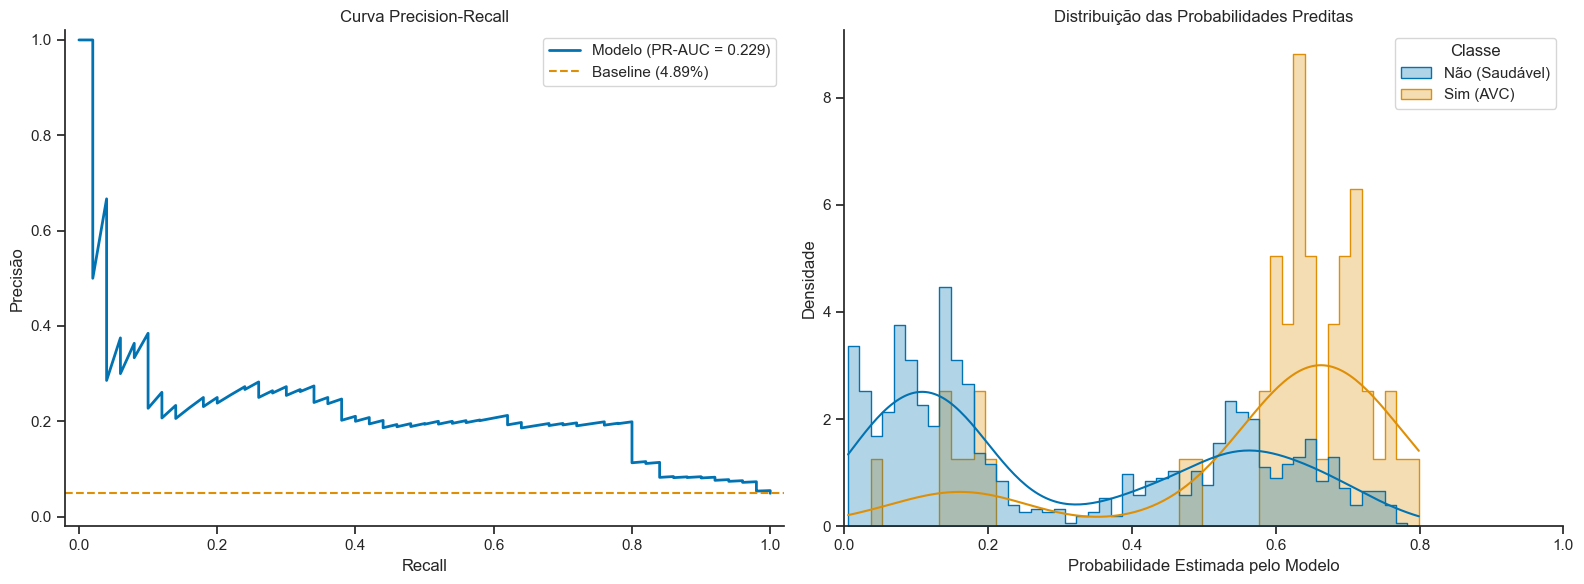


Experimento: RandomForest_SMOTETomek
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Melhores Parâmetros:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': 5}
Melhor PR-AUC (CV): 0.1467
Análise de Desempenho Clínico (PR-AUC: 0.1794)

Métricas por Limiar de Decisão:
 Threshold Precision   Recall F1-Score Falsos Positivos / Positivo Real
       0.1   8.7398% 86.0000%   0.1587                             10.4
       0.2   9.1904% 84.0000%   0.1657                              9.9
       0.3  10.0000% 84.0000%   0.1787                              9.0
       0.4  11.3514% 84.0000%   0.2000                              7.8
       0.5  13.0435% 84.0000%   0.2258                              6.7
       0.6  13.7652% 68.0000%   0.2290                              6.3
       0.7  18.7500% 36.0000%   0.2466                              4.3
       0.8   0.0000%  0.0000%   0.0000                

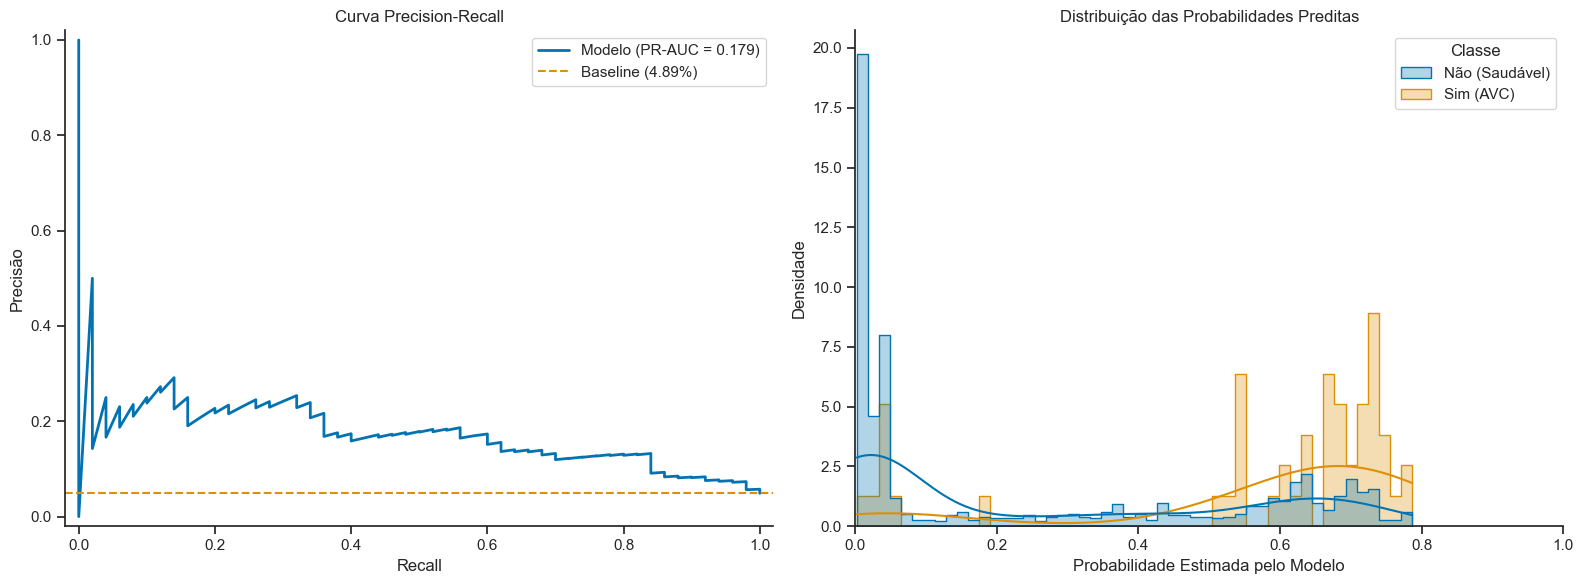


Experimento: XGBoost
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Melhores Parâmetros:
{'model__subsample': 0.8, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0.5, 'model__colsample_bytree': 0.8}
Melhor PR-AUC (CV): 0.1812
Análise de Desempenho Clínico (PR-AUC: 0.2644)

Métricas por Limiar de Decisão:
 Threshold Precision    Recall F1-Score Falsos Positivos / Positivo Real
       0.1   4.8924% 100.0000%   0.0933                             19.4
       0.2   5.4054% 100.0000%   0.1026                             17.5
       0.3   8.3333%  86.0000%   0.1519                             11.0
       0.4   9.0517%  84.0000%   0.1634                             10.0
       0.5  11.5385%  84.0000%   0.2029                              7.7
       0.6  18.5930%  74.0000%   0.2972                              4.4
       0.7  31.2500%  10.0000%   0.1515                              2.2
       0.8   0.0000%   0.0000%   0.0000    

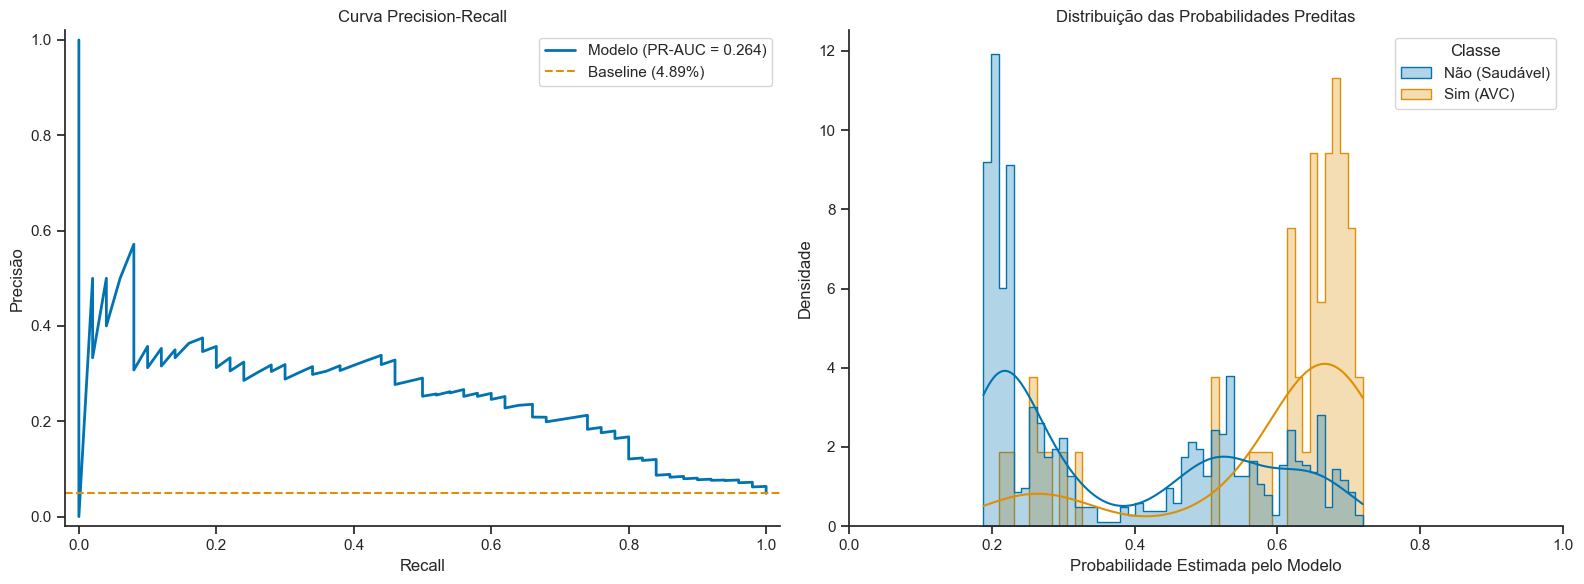


Experimento: XGBoost_SMOTETomek
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Melhores Parâmetros:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0.5, 'model__colsample_bytree': 0.6}
Melhor PR-AUC (CV): 0.1598
Análise de Desempenho Clínico (PR-AUC: 0.1918)

Métricas por Limiar de Decisão:
 Threshold Precision   Recall F1-Score Falsos Positivos / Positivo Real
       0.1   6.3636% 98.0000%   0.1195                             14.7
       0.2   8.6444% 88.0000%   0.1574                             10.6
       0.3   9.4298% 86.0000%   0.1700                              9.6
       0.4   9.9034% 82.0000%   0.1767                              9.1
       0.5  11.8182% 78.0000%   0.2053                              7.5
       0.6  18.4615% 72.0000%   0.2939                              4.4
       0.7  26.1905% 22.0000%   0.2391                              2.8
       0.8   0.0000%  0.0000%   0.0000  

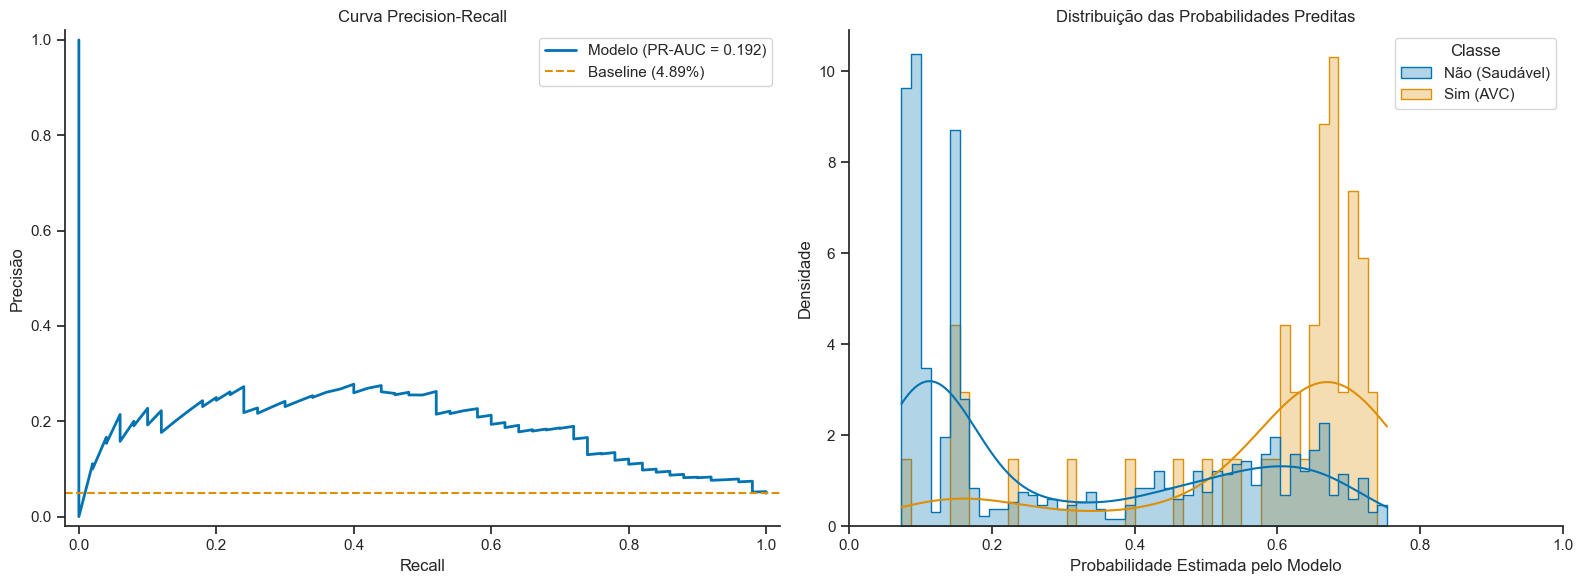


Experimento: LogisticRegression
Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Melhores Parâmetros:
{'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': np.float64(0.42813323987193913)}
Melhor PR-AUC (CV): 0.1912
Análise de Desempenho Clínico (PR-AUC: 0.2587)

Métricas por Limiar de Decisão:
 Threshold Precision   Recall F1-Score Falsos Positivos / Positivo Real
       0.1   7.3025% 98.0000%   0.1359                             12.7
       0.2   7.9190% 86.0000%   0.1450                             11.6
       0.3   9.2715% 84.0000%   0.1670                              9.8
       0.4  11.1406% 84.0000%   0.1967                              8.0
       0.5  13.1148% 80.0000%   0.2254                              6.6
       0.6  17.1806% 78.0000%   0.2816                              4.8
       0.7  20.4545% 72.0000%   0.3186                              3.9
       0.8  22.8571% 48.0000%   0.3097                              3.4

-----------------------------------------------------------------



c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


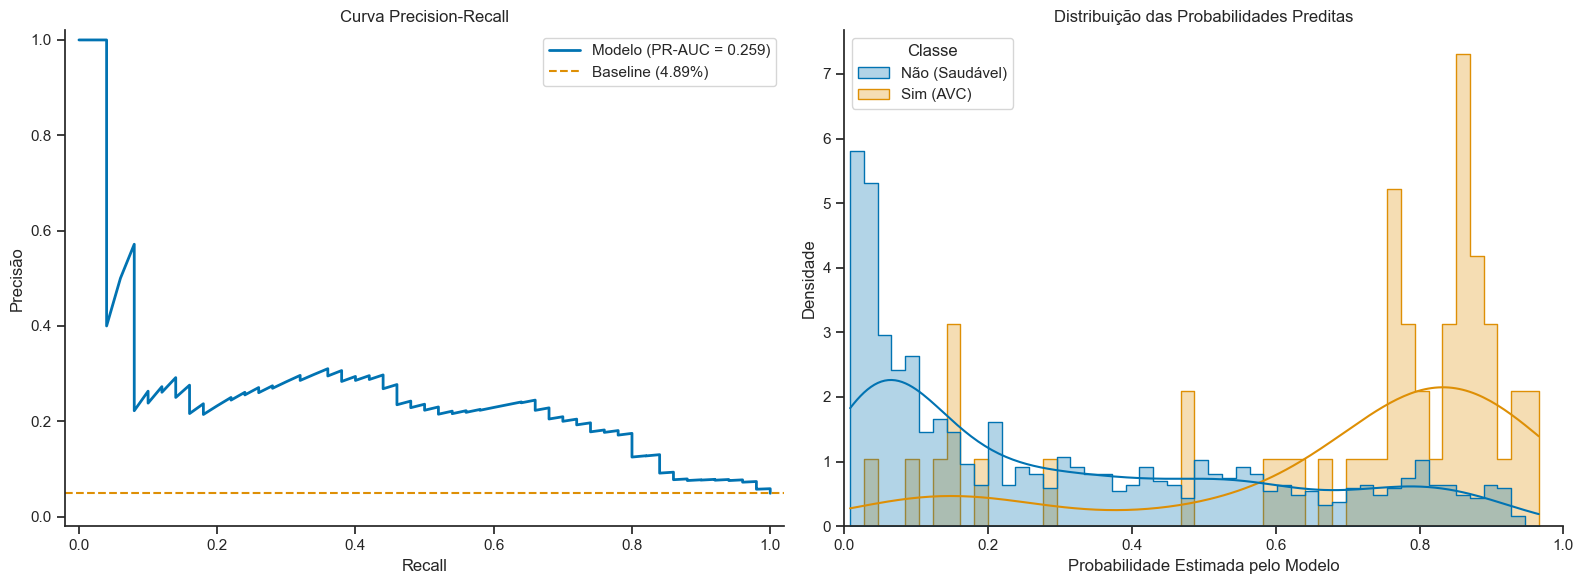

In [40]:
results = {}

for experiment_key, config in experiments.items():
    print(f"\n{'='*50}")
    print(f"Experimento: {experiment_key}")
    print(f"{'='*50}")

    pipeline = build_pipeline(
        model=config["model"],
        continuous_vars=continuous_vars,
        categorical_vars=categorical_vars,
        binary_vars=binary_vars,
        imputation_method="knn",
        apply_log=True,
        log_variables=["avg_glucose_level", "bmi"],
        sampler=config["sampler"],
    )

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config["param_dist"],
        n_iter=50,
        scoring=scorer,
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1,
        refit=True,  # re-treina com melhores params em todo X_train
    )

    search.fit(X_train, y_train)

    print("\nMelhores Parâmetros:")
    print(search.best_params_)
    print(f"Melhor PR-AUC (CV): {search.best_score_:.4f}")

    # avaliação final no X_test — único contato com holdout
    y_prob = search.best_estimator_.predict_proba(X_test)[:, 1]
    # metrics = evaluate_model(y_test, y_prob, threshold=0.5)

    pr_auc, threshold_results = evaluate_model_v2(y_test, y_prob)

    results[experiment_key] = {
        "best_params": search.best_params_,
        "cv_pr_auc": search.best_score_,
        "test_pr_auc": pr_auc,
        "threshold_results": threshold_results,
        "search": search,
    }

In [41]:
summary_list = []

for key, v in results.items():
    df_temp = v["threshold_results"].copy()

    df_temp.insert(0, "Experimento", key)
    df_temp.insert(1, "CV PR-AUC", v["cv_pr_auc"])
    df_temp.insert(2, "Test PR-AUC", v["test_pr_auc"])

    summary_list.append(df_temp)

summary = pd.concat(summary_list, ignore_index=True)

# 4. Ordena pelo poder geral do modelo (Test PR-AUC) e depois pelo threshold operacional
summary = summary.sort_values(
    by=["Test PR-AUC", "Threshold"],
    ascending=[False, True]
)

# Exibe o relatório final na tela
print(summary.to_string(index=False))

            Experimento  CV PR-AUC  Test PR-AUC  Threshold Precision    Recall F1-Score Falsos Positivos / Positivo Real
                XGBoost   0.181189     0.264376        0.1   4.8924% 100.0000%   0.0933                             19.4
                XGBoost   0.181189     0.264376        0.2   5.4054% 100.0000%   0.1026                             17.5
                XGBoost   0.181189     0.264376        0.3   8.3333%  86.0000%   0.1519                             11.0
                XGBoost   0.181189     0.264376        0.4   9.0517%  84.0000%   0.1634                             10.0
                XGBoost   0.181189     0.264376        0.5  11.5385%  84.0000%   0.2029                              7.7
                XGBoost   0.181189     0.264376        0.6  18.5930%  74.0000%   0.2972                              4.4
                XGBoost   0.181189     0.264376        0.7  31.2500%  10.0000%   0.1515                              2.2
                XGBoost   0.1811

In [42]:
for key, v in results.items():
    v["y_prob"] = v["search"].best_estimator_.predict_proba(X_test)[:, 1]

In [43]:
"""
Bootstrap 95% confidence intervals (percentile method) for test-set metrics.

Paste after the experiment loop. Requires `results[key]["y_prob"]` to be cached
(see followup_analyses.py) and `y_test` in scope.

Output: `ci_summary` DataFrame, one row per experiment, ready for Table 3.
"""

import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

N_BOOTSTRAP = 1000
THRESHOLD = 0.5
RANDOM_SEED = 42

LABEL_MAP = {
    "RandomForest": "Random Forest",
    "RandomForest_SMOTETomek": "Random Forest + SMOTE/Tomek",
    "XGBoost": "XGBoost",
    "XGBoost_SMOTETomek": "XGBoost + SMOTE/Tomek",
    "LogisticRegression": "Regressão Logística",
}


def compute_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "pr_auc": average_precision_score(y_true, y_prob),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }


def bootstrap_ci(y_true, y_prob, n_boot=N_BOOTSTRAP, threshold=THRESHOLD, seed=RANDOM_SEED):
    """Return {metric: {"point", "lower", "upper"}} using percentile bootstrap."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)

    point = compute_metrics(y_true, y_prob, threshold)
    boot = {metric: [] for metric in point}

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        if yt.min() == yt.max():  # resample without both classes: AUC undefined
            continue
        for metric, value in compute_metrics(yt, y_prob[idx], threshold).items():
            boot[metric].append(value)

    return {
        metric: {
            "point": point[metric],
            "lower": float(np.percentile(boot[metric], 2.5)),
            "upper": float(np.percentile(boot[metric], 97.5)),
        }
        for metric in point
    }


def fmt(ci, metric, digits):
    return (
        f"{ci[metric]['point']:.{digits}f} "
        f"[{ci[metric]['lower']:.{digits}f} – {ci[metric]['upper']:.{digits}f}]"
    )


ci_rows = []
for key, v in results.items():
    ci = bootstrap_ci(y_test, v["y_prob"])
    ci_rows.append({
        "Experimento": LABEL_MAP.get(key, key),
        "CV PR-AUC": f"{v['cv_pr_auc']:.4f}",
        "Test PR-AUC [IC 95%]": fmt(ci, "pr_auc", 4),
        "Test ROC-AUC [IC 95%]": fmt(ci, "roc_auc", 4),
        "Test Precision [IC 95%]": fmt(ci, "precision", 4),
        "Test F1-Score [IC 95%]": fmt(ci, "f1", 4),
        "Test Recall [IC 95%]": fmt(ci, "recall", 2),
    })

ci_summary = pd.DataFrame(ci_rows)
print(f"Table 3 — percentile bootstrap, B={N_BOOTSTRAP}, threshold={THRESHOLD}, seed={RANDOM_SEED}")
print(ci_summary.to_string(index=False))

Table 3 — percentile bootstrap, B=1000, threshold=0.5, seed=42
                Experimento CV PR-AUC     Test PR-AUC [IC 95%]    Test ROC-AUC [IC 95%]  Test Precision [IC 95%]   Test F1-Score [IC 95%] Test Recall [IC 95%]
              Random Forest    0.1605 0.2287 [0.1514 – 0.3377] 0.8296 [0.7728 – 0.8839] 0.1159 [0.0826 – 0.1492] 0.2025 [0.1485 – 0.2532]   0.80 [0.69 – 0.91]
Random Forest + SMOTE/Tomek    0.1467 0.1794 [0.1221 – 0.2903] 0.8096 [0.7560 – 0.8659] 0.1304 [0.0945 – 0.1667] 0.2258 [0.1676 – 0.2803]   0.84 [0.73 – 0.94]
                    XGBoost    0.1812 0.2644 [0.1817 – 0.3960] 0.8451 [0.7881 – 0.8987] 0.1154 [0.0829 – 0.1491] 0.2029 [0.1505 – 0.2530]   0.84 [0.73 – 0.94]
      XGBoost + SMOTE/Tomek    0.1598 0.1918 [0.1358 – 0.2834] 0.8254 [0.7687 – 0.8794] 0.1182 [0.0838 – 0.1530] 0.2053 [0.1492 – 0.2585]   0.78 [0.66 – 0.89]
        Regressão Logística    0.1912 0.2587 [0.1742 – 0.3705] 0.8391 [0.7824 – 0.8924] 0.1311 [0.0936 – 0.1690] 0.2254 [0.1661 – 0.2817]   0.

In [44]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
 
THRESHOLD = 0.5
y_test_arr = np.asarray(y_test)

# %% Absolute confusion counts at the default threshold (needed to cite FP/FN in the text)
for key, v in results.items():
    tn, fp, fn, tp = confusion_matrix(
        y_test_arr, (v["y_prob"] >= THRESHOLD).astype(int)
    ).ravel()
    print(f"{key:28s} TP={tp:3d} FP={fp:3d} FN={fn:3d} TN={tn:3d}")
 
# %% 1. McNemar with Logistic Regression as reference + Holm correction
def mcnemar_test(y_true, y_pred_ref, y_pred_chal):
    correct_ref = y_pred_ref == y_true
    correct_chal = y_pred_chal == y_true
    n01 = int(np.sum(~correct_ref & correct_chal))  # reference wrong, challenger right
    n10 = int(np.sum(correct_ref & ~correct_chal))  # reference right, challenger wrong
    result = mcnemar([[0, n01], [n10, 0]], exact=(n01 + n10) < 25, correction=True)
    return n01, n10, float(result.pvalue)
 
 
REFERENCE = "LogisticRegression"
y_pred_ref = (results[REFERENCE]["y_prob"] >= THRESHOLD).astype(int)
 
rows = []
for key in (k for k in results if k != REFERENCE):
    y_pred_chal = (results[key]["y_prob"] >= THRESHOLD).astype(int)
    n01, n10, p = mcnemar_test(y_test_arr, y_pred_ref, y_pred_chal)
    rows.append({"challenger": key, "ref_wrong_chal_right": n01,
                 "ref_right_chal_wrong": n10, "p_raw": p})
 
mcnemar_df = pd.DataFrame(rows)
mcnemar_df["p_holm"] = multipletests(mcnemar_df["p_raw"], method="holm")[1]
print(mcnemar_df.to_string(index=False))
 
# %% 2. Logistic Regression coefficients with bootstrap CI (resampling the TRAINING set)
best_lr = results[REFERENCE]["search"].best_estimator_
 
 
def get_feature_names(pipeline):
    for _, step in pipeline.steps:
        if isinstance(step, ColumnTransformer):
            return step.get_feature_names_out()
    raise ValueError("No ColumnTransformer found in pipeline")
 
 
feature_names = get_feature_names(best_lr)
coef_point = best_lr.named_steps["model"].coef_.ravel()
assert len(feature_names) == len(coef_point)
 
N_BOOT_COEF = 500
rng = np.random.default_rng(42)
X_tr = X_train.reset_index(drop=True)
y_tr = y_train.reset_index(drop=True)
coef_boot = np.empty((N_BOOT_COEF, len(coef_point)))
 
for i in range(N_BOOT_COEF):
    idx = rng.integers(0, len(X_tr), size=len(X_tr))
    fitted = clone(best_lr).fit(X_tr.iloc[idx], y_tr.iloc[idx])
    boot_coef = fitted.named_steps["model"].coef_.ravel()
    assert boot_coef.shape == coef_point.shape, "Feature set changed in bootstrap sample"
    coef_boot[i] = boot_coef
 
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef_point,
    "ci_lower": np.percentile(coef_boot, 2.5, axis=0),
    "ci_upper": np.percentile(coef_boot, 97.5, axis=0),
    "odds_ratio": np.exp(coef_point),
    # Fraction of bootstrap fits in which L1 kept the feature (stability of selection)
    "selection_freq": (coef_boot != 0).mean(axis=0),
}).sort_values("coef", key=np.abs, ascending=False)
 
print(coef_df.to_string(index=False))
print("intercept:", best_lr.named_steps["model"].intercept_[0])
 
# %% 3. Is bmi missingness associated with the target?
raw = pd.read_csv("../data/raw/stroke.csv")
missing_bmi = raw["bmi"].isna()
 
print(pd.crosstab(missing_bmi, raw["stroke"], margins=True))
print(f"stroke rate | bmi missing : {raw.loc[missing_bmi, 'stroke'].mean():.4f}")
print(f"stroke rate | bmi present : {raw.loc[~missing_bmi, 'stroke'].mean():.4f}")
print(f"share of positives with missing bmi: "
      f"{raw.loc[missing_bmi, 'stroke'].sum() / raw['stroke'].sum():.4f}")
 
# %% 4. XGBoost threshold table (already computed by evaluate_model_v2)
print(results["XGBoost"]["threshold_results"].to_string(index=False))

RandomForest                 TP= 40 FP=305 FN= 10 TN=667
RandomForest_SMOTETomek      TP= 42 FP=280 FN=  8 TN=692
XGBoost                      TP= 42 FP=322 FN=  8 TN=650
XGBoost_SMOTETomek           TP= 39 FP=291 FN= 11 TN=681
LogisticRegression           TP= 40 FP=265 FN= 10 TN=707
             challenger  ref_wrong_chal_right  ref_right_chal_wrong        p_raw       p_holm
           RandomForest                    15                    55 3.140785e-06 9.422355e-06
RandomForest_SMOTETomek                    26                    39 1.366410e-01 1.366410e-01
                XGBoost                     8                    63 1.468418e-10 5.873670e-10
     XGBoost_SMOTETomek                    21                    48 1.747872e-03 3.495743e-03


c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalt

                       feature      coef  ci_lower  ci_upper  odds_ratio  selection_freq
                           age  1.862986  1.651720  2.201658    6.442949           1.000
                  hypertension  0.624597  0.155653  1.061988    1.867493           0.998
            work_type_children  0.616889 -0.846908  2.447448    1.853154           0.890
   smoking_status_never_smoked -0.308944 -0.743180  0.000000    0.734222           0.964
       work_type_self-employed -0.213042 -0.726250  0.005464    0.808122           0.850
             avg_glucose_level  0.200893  0.050401  0.357860    1.222494           1.000
         smoking_status_smokes  0.172164 -0.178584  0.591920    1.187873           0.748
                  ever_married -0.170504 -0.659949  0.369072    0.843240           0.912
          residence_type_rural -0.166644 -0.519919  0.000000    0.846501           0.836
                 heart_disease  0.134498 -0.272618  0.596920    1.143962           0.898
                   ge

c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## Coeficientes da RL final (IC 95% via bootstrap)

In [45]:
from sklearn.base import clone
from sklearn.utils import resample

N_BOOTSTRAP_COEF = 1000
RANDOM_SEED = 42

lr_pipeline = results["LogisticRegression"]["search"].best_estimator_
feature_names = lr_pipeline.named_steps["preprocessor"].get_feature_names_out()
point_coefs = lr_pipeline.named_steps["model"].coef_[0]

rng = np.random.default_rng(RANDOM_SEED)
boot_coefs = np.zeros((N_BOOTSTRAP_COEF, len(point_coefs)))

X_train_arr = X_train.reset_index(drop=True)
y_train_arr = y_train.reset_index(drop=True)
n_train = len(X_train_arr)

for i in range(N_BOOTSTRAP_COEF):
    idx = rng.integers(0, n_train, size=n_train)
    Xb, yb = X_train_arr.iloc[idx], y_train_arr.iloc[idx]

    if yb.nunique() < 2:
        boot_coefs[i] = np.nan
        continue

    model_b = clone(lr_pipeline)
    model_b.set_params(**results["LogisticRegression"]["best_params"])
    model_b.fit(Xb, yb)
    boot_coefs[i] = model_b.named_steps["model"].coef_[0]

ci_lower = np.nanpercentile(boot_coefs, 2.5, axis=0)
ci_upper = np.nanpercentile(boot_coefs, 97.5, axis=0)

coef_summary = pd.DataFrame({
    "Variável": feature_names,
    "Coeficiente": point_coefs,
    "Odds Ratio": np.exp(point_coefs),
    "IC 95% Inferior": ci_lower,
    "IC 95% Superior": ci_upper,
    "Zerado pela L1": np.isclose(point_coefs, 0.0),
}).sort_values("Coeficiente", key=np.abs, ascending=False)

print(coef_summary.to_string(index=False))
print(f"\nVariáveis zeradas pela L1: {coef_summary.loc[coef_summary['Zerado pela L1'], 'Variável'].tolist()}")


c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalt

                      Variável  Coeficiente  Odds Ratio  IC 95% Inferior  IC 95% Superior  Zerado pela L1
                           age     1.862986    6.442949         1.661069         2.201262           False
                  hypertension     0.624597    1.867493         0.145011         1.066629           False
            work_type_children     0.616889    1.853154        -0.875645         2.345295           False
   smoking_status_never_smoked    -0.308944    0.734222        -0.737656         0.000000           False
       work_type_self-employed    -0.213042    0.808122        -0.729312         0.016662           False
             avg_glucose_level     0.200893    1.222494         0.053617         0.355064           False
         smoking_status_smokes     0.172164    1.187873        -0.146363         0.587667           False
                  ever_married    -0.170504    0.843240        -0.681416         0.360116           False
          residence_type_rural    -0.166644   

c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Personal\Projects\tcc\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalt

## Taxa de AVC entre registros com `bmi` ausente

In [46]:
df_raw = pd.read_csv("../data/raw/stroke.csv")
df_raw = clean_stroke_data(df_raw)

bmi_missing = df_raw[df_raw["bmi"].isna()]
bmi_present = df_raw[df_raw["bmi"].notna()]

print(f"Registros com bmi ausente: {len(bmi_missing)}")
print(f"Taxa de AVC (bmi ausente):  {bmi_missing['stroke'].mean():.4%}")
print(f"Taxa de AVC (bmi presente): {bmi_present['stroke'].mean():.4%}")
print(f"Taxa de AVC (geral):        {df_raw['stroke'].mean():.4%}")


Registros com bmi ausente: 201
Taxa de AVC (bmi ausente):  19.9005%
Taxa de AVC (bmi presente): 4.2584%
Taxa de AVC (geral):        4.8738%


## Tabela de limiares do XGBoost (formato Tabela 4) — checar FP/TP a 0,1

In [47]:
xgb_threshold_table = results["XGBoost"]["threshold_results"]
print(xgb_threshold_table.to_string(index=False))


 Threshold Precision    Recall F1-Score Falsos Positivos / Positivo Real
       0.1   4.8924% 100.0000%   0.0933                             19.4
       0.2   5.4054% 100.0000%   0.1026                             17.5
       0.3   8.3333%  86.0000%   0.1519                             11.0
       0.4   9.0517%  84.0000%   0.1634                             10.0
       0.5  11.5385%  84.0000%   0.2029                              7.7
       0.6  18.5930%  74.0000%   0.2972                              4.4
       0.7  31.2500%  10.0000%   0.1515                              2.2
       0.8   0.0000%   0.0000%   0.0000                              nan
